<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Advertising_ANN_Classification_Notebook_Jagdish_Mane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2.1: Building an Artificail Neural Network

### Predicting Online Ad Clicks Using an Artificial Neural Network

A classification model to predict whether a user will click on an online advertisement using demographic and behavioral attributes. This Artificial Neural Network ANN built with TensorFlow.

1. This Notebook is tested on Google Colab.
2. Ensure to upload the dataset file "M2-Advertising-Dataset.csv"
3. Some part of Code has been generated using Google Colab compose subagent inbuildint in Colab Tools.

## 1. Load Dataset into Pandas dataframe

In [45]:
import numpy as np
import pandas as pd

data_path = "M2-Advertising-Dataset.csv"
df = pd.read_csv(data_path)

## 2. Data Preprocessing and Feature engineering

### 2.1 Data Analysis

In [46]:
print("\nShape:", df.shape)
print("="*100)
print("Data Types:\n", df.dtypes)
print("="*100)
print("\nFirst five rows:")
print("="*100)
display(df.head())


Shape: (1000, 10)
Data Types:
 Daily Time Spent on Site    float64
Age                           int64
Area Income                 float64
Daily Internet Usage        float64
Ad Topic Line                object
City                         object
Male                          int64
Country                      object
Timestamp                    object
Clicked on Ad                 int64
dtype: object

First five rows:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [61]:
print("="*100)
print("\nMissing values per column: ")
print(df.isnull().sum())
print("="*100)
print("\nDuplicate rows: ", df.duplicated().sum())
print("="*100)
print("\nTarget distribution: ")
print("="*100)
print(df["Clicked on Ad"].value_counts())
print("="*100)
print("\nSummary statistics: ")
display(df.describe())


Missing values per column: 
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
Hour                        0
DayofWeek                   0
Month                       0
Country_Freq                0
dtype: int64

Duplicate rows:  0

Target distribution: 
Clicked on Ad
0    500
1    500
Name: count, dtype: int64

Summary statistics: 


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Timestamp,Clicked on Ad,Hour,DayofWeek,Month,Country_Freq
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,2016-04-10 10:34:06.636000256,0.50000,11.660000,3.064000,3.817000,0.005016
min,32.600000,19.000000,13996.500000,104.780000,0.000000,2016-01-01 02:52:10,0.00000,0.000000,0.000000,1.000000,0.001000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,2016-02-18 02:55:42,0.00000,6.000000,1.000000,2.000000,0.004000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,2016-04-07 17:27:29.500000,0.50000,12.000000,3.000000,4.000000,0.005000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,2016-05-31 03:18:14,1.00000,18.000000,5.000000,5.000000,0.006000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,2016-07-24 00:22:16,1.00000,23.000000,6.000000,7.000000,0.009000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,NaN,0.50025,6.960952,1.998474,1.926973,0.001752


In [48]:
print("Unique Object columns:")
object_cols = df.select_dtypes(include='object')
print(object_cols.nunique())

Unique Object columns:
Ad Topic Line    1000
City              969
Country           237
Timestamp        1000
dtype: int64


- There are 1000 rows and 10 columns in the dataset.
- There are no missing values or duplicated values.
- Target Column is "Clicked on Ad" , distrubuted equally 500 samples for each yes (1) and no (0) values.
- There are 969 Unique cities out of 1000 rows - so very high cardinality.


### 2.2 Feature Engineering

- *Timestamp*: Covert to Hours,  DayofWeek and Month.
- *Country*: 237 values, encode as Country_Frequence
- *City*: Drop City due to high cardinality
- *Ad Topic Line*: its free text filed , it needs NLP for feature extraction. So we drop this column

In [56]:
### Convert Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayofWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

print("Timestamp converted to Hours, DayofWeek and Month")
display(df[['Timestamp','Hour', 'DayofWeek', 'Month']].head())

Timestamp converted to Hours, DayofWeek and Month


,Timestamp,Hour,DayofWeek,Month
0,2016-03-27 00:53:11,0,6,3
1,2016-04-04 01:39:02,1,0,4
2,2016-03-13 20:35:42,20,6,3
3,2016-01-10 02:31:19,2,6,1
4,2016-06-03 03:36:18,3,4,6


In [55]:
### Encode Country values
country_freq = df["Country"].value_counts(normalize=True)
df["Country_Freq"] = df["Country"].map(country_freq)

print("Country values encoded as Country_Freq")
display(df[['Country', 'Country_Freq']].head())

Country values encoded as Country_Freq


,Country,Country_Freq
0,Tunisia,0.004
1,Nauru,0.003
2,San Marino,0.003
3,Italy,0.005
4,Iceland,0.003


In [57]:
### Drop text and timestamp columns
drop_cols = ["Ad Topic Line", "City", "Country", "Timestamp"]
df_model = df.drop(columns=drop_cols)

print("Modeling dataset shape:", df_model.shape)
display(df_model.head())

Modeling dataset shape: (1000, 10)


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Hour,DayofWeek,Month,Country_Freq
0,68.95,35,61833.90,256.09,0,0,0,6,3,0.004
1,80.23,31,68441.85,193.77,1,0,1,0,4,0.003
2,69.47,26,59785.94,236.50,0,0,20,6,3,0.003
3,74.15,29,54806.18,245.89,1,0,2,6,1,0.005
4,68.37,35,73889.99,225.58,0,0,3,4,6,0.003


### 2.3 Exploratory Data Analyis

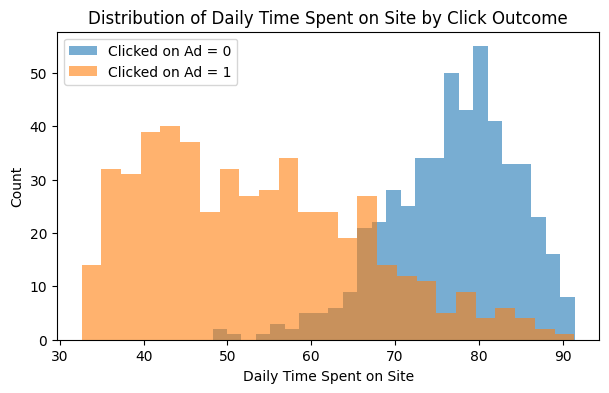

In [66]:
### EDA
import matplotlib.pyplot as plt
numeric_features = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage"
]

def plot_figure(feature):
   plt.figure(figsize=(7, 4))
   for label in sorted(df["Clicked on Ad"].unique()):
       subset = df[df["Clicked on Ad"] == label][feature]
       plt.hist(subset, bins=25, alpha=0.6, label=f"Clicked on Ad = {label}")
   plt.title(f"Distribution of {feature} by Click Outcome")
   plt.xlabel(feature)
   plt.ylabel("Count")
   plt.legend()
   plt.show()

plot_figure("Daily Time Spent on Site")

**Distribution of Daily time spent on site:**
- Blue distribution = User who did not click on Ad.
- Orange distribution = User who clicked on Ad.
- User who spend less time on the site are more likely to click on the Ad.
- Users spending less time may be caual visitions, less enaged with website are more likely to respond to the Advertiments

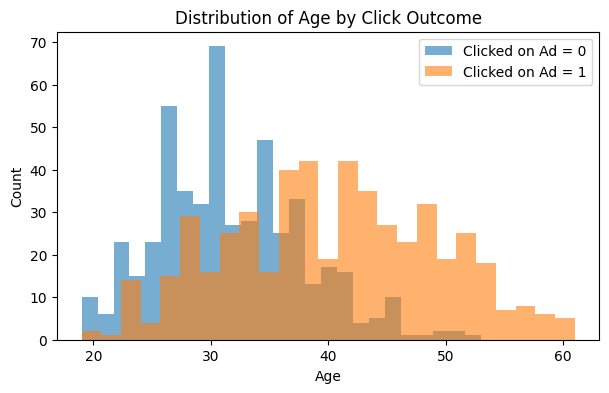

In [67]:
plot_figure("Age")

**Distribution of Age by Click Outcome**
- Users with age group between 35 to 55 are more likely click on the Ad.
- Users with age group younger age group are less likely to click on the Ad.
- Possible reason could be the Ad. is more relevent to older users like share market investments

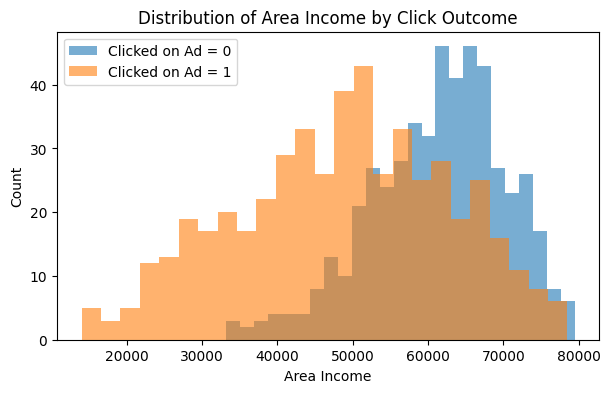

In [68]:
plot_figure("Area Income")

**Distribution of Area Income**
- Users from lower to Middle income areas (35K to 65K) range are more likely to click on the Ad.
- The Ad. could be more attactive to lowe income users.

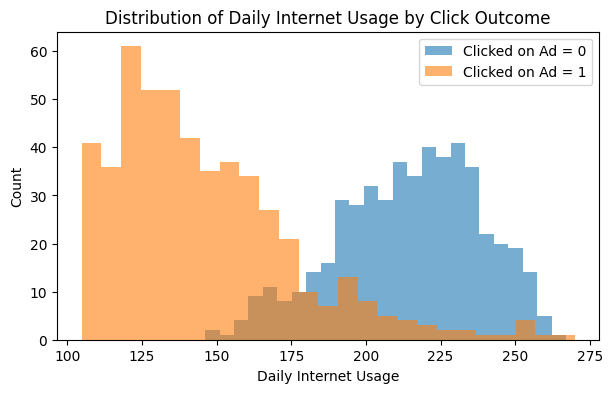

In [69]:
plot_figure("Daily Internet Usage")

**Daily Internet Usage**
- Users with higher daily internet usage did not click the Ad.
- The users with less internet usage are likely to click on the Ad.(less 150 mins daily usage)
- Heavy internet users may ignore ads more often, while lighter internet users may be more responsive to them.


#### Correlation

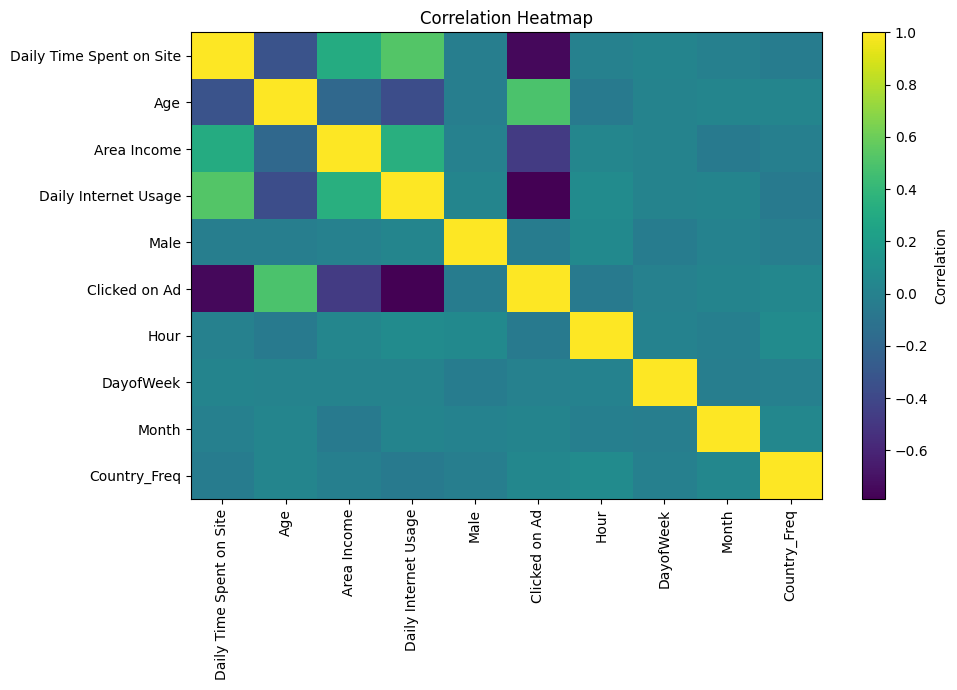

Feature correlation with target 'Clicked on Ad':
Clicked on Ad               1.000000
Age                         0.492531
Country_Freq                0.037682
Month                       0.016095
DayofWeek                   0.002003
Male                       -0.038027
Hour                       -0.047431
Area Income                -0.476255
Daily Time Spent on Site   -0.748117
Daily Internet Usage       -0.786539
Name: Clicked on Ad, dtype: float64


In [70]:
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

target_corr = corr["Clicked on Ad"].sort_values(ascending=False)
print("Feature correlation with target 'Clicked on Ad':")
print(target_corr)

- Age feature is more correlated to Clicked on Ad. then any other feature.
- Daily Time Spent on Site and Daily Internet Usage has strong negative correlation with Clicked on Ad.
- Area income - Neagative correlation.
- Male, Hour, DayofWeek, Month, Country_Freq - Very week correlation.
- Users more likely to click on the add are who spend less time on the site, use the internet less daily, are older, and come from lower-to-medium income areas.

## 3. Split Train and Test dataset

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

X = df_model.drop(columns=["Clicked on Ad"])    ## Feature dataset
y = df_model["Clicked on Ad"]                   ## target Dataset

### 80% Train, 20% Test Split.
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)


X_train shape: (800, 9)
X_test shape: (200, 9)


## 4. Scale the data using StandardScaler

In [81]:
### Scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
Clicked on Ad
1    0.5
0    0.5
Name: proportion, dtype: float64
y_test distribution:
Clicked on Ad
1    0.5
0    0.5
Name: proportion, dtype: float64


## 5. Build ANN Classifier

In [91]:
import tensorflow as tf
from tensorflow import keras

n_features = X_train_scaled.shape[1]
print("Number of features:", n_features)

### Function to evalute the models.
def evaluate_model(model, X_test, y_text):
   y_pred_prod = model.predict(X_test, verbose=0)
   y_pred = (y_pred_prod >= 0.5).astype(int)


   print("Accuracy:", accuracy_score(y_test, y_pred))
   print("Precision:", precision_score(y_test, y_pred))
   print("Recall:", recall_score(y_test, y_pred))
   print("F1 Score:", f1_score(y_test, y_pred))
   print("ROC AUC:", roc_auc_score(y_test, y_pred_prod))
   print("\nConfusion Matrix:")
   print(confusion_matrix(y_test, y_pred))
   print("\nClassification Report:")
   print(classification_report(y_test, y_pred, target_names=["No Click", "Clicked"]))

Number of features: 9


#### 5.1 Experiment 1: Simple Baseline ANN

- Simple ANN Architecutre with ReLU activation and Adam Optimizer
- Learning rate 0.0001
- Batch size 32

In [92]:
model_1 = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_1 = model_1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(model_1, X_test_scaled, y_test)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5125 - loss: 0.7311 - val_accuracy: 0.5500 - val_loss: 0.6816
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5703 - loss: 0.6707 - val_accuracy: 0.5813 - val_loss: 0.6346
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6203 - loss: 0.6217 - val_accuracy: 0.6625 - val_loss: 0.5916
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7172 - loss: 0.5784 - val_accuracy: 0.7375 - val_loss: 0.5483
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8078 - loss: 0.5336 - val_accuracy: 0.8250 - val_loss: 0.5046
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8734 - loss: 0.4891 - val_accuracy: 0.8938 - val_loss: 0.4598
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9047 - loss: 0.4426 - val_accuracy: 0.9000 - val_loss: 0.4147
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9281 - loss: 0.3958 - val_accuracy: 0.9125

### 5.1 - Experiment 1 - batch_size = 25, Learning rate 0.001

In [90]:
### Define Model Architecutre
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[n_features]),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])

### Complie the Model
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

### Train the Model
num_epochs = 5000
batch_size = 25
history = model.fit(X_train_scaled, y_train, epochs=num_epochs, batch_size=batch_size, validation_split=0.2)

### Train the Model

# ### Define a function to build model
# def build_model(hidden_layers=(16, 8), activation="relu", dropout=0.0, l2=0.0, lr=0.001):
#     reg = keras.regularizers.l2(l2)

Epoch 1/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2448 - val_loss: 0.0942
Epoch 2/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1517 - val_loss: 0.0887
Epoch 3/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1308 - val_loss: 0.0675
Epoch 4/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1054 - val_loss: 0.0711
Epoch 5/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1099 - val_loss: 0.0587
Epoch 6/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0969 - val_loss: 0.0746
Epoch 7/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0940 - val_loss: 0.0557
Epoch 8/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0875 - val_loss: 0.0714
Epoch 9/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0766 - val_loss: 0.0523
Epoch 10/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0742 - val_loss: 0.0537
Epoch 11/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0715 - val_loss: 0.0537
Epoch 12/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

KeyboardInterrupt: 

6.

## Task 1 & 2: Load Dataset, Data Cleaning, and Initial Exploration

The dataset contains user browsing behavior, demographic details, and the target variable `Clicked on Ad`.

In [ ]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Clicked on Ad"].value_counts())

print("\nSummary statistics:")
display(df.describe())

### Data Quality Summary

The original report states that the dataset contains:

- 1,000 records
- 10 columns
- No missing values
- No duplicate rows
- A balanced target distribution: 500 clicked and 500 not clicked

Because the target is balanced, accuracy is a meaningful metric and class-imbalance correction is not required.

## Preprocessing and Feature Engineering

Some columns need special handling before training a numeric ANN model:

- `Ad Topic Line`: free-text field with very high uniqueness; dropped because it needs separate NLP feature extraction.
- `City`: very high cardinality; dropped to avoid sparse one-hot encoding and overfitting.
- `Country`: frequency encoded as `Country_Freq`.
- `Timestamp`: converted into `Hour`, `DayOfWeek`, and `Month`.

In [ ]:
# Convert Timestamp into datetime features
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month

# Frequency encode Country
country_freq = df["Country"].value_counts(normalize=True)
df["Country_Freq"] = df["Country"].map(country_freq)

# Drop high-cardinality/free-text/raw timestamp columns
drop_cols = ["Ad Topic Line", "City", "Country", "Timestamp"]
df_model = df.drop(columns=drop_cols)

print("Modeling dataset shape:", df_model.shape)
display(df_model.head())

print("\nModeling columns:")
print(df_model.columns.tolist())

## Exploratory Data Analysis

The following plots show the distribution of key numeric predictors split by ad-click outcome.

In [ ]:
numeric_features = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage"
]

for feature in numeric_features:
    plt.figure(figsize=(7, 4))
    for label in sorted(df["Clicked on Ad"].unique()):
        subset = df[df["Clicked on Ad"] == label][feature]
        plt.hist(subset, bins=25, alpha=0.6, label=f"Clicked on Ad = {label}")
    plt.title(f"Distribution of {feature} by Click Outcome")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

### Correlation Analysis

This heatmap shows how strongly each modeling feature is linearly related to the target variable.

In [ ]:
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

target_corr = corr["Clicked on Ad"].sort_values(ascending=False)
print("Feature correlation with target 'Clicked on Ad':")
print(target_corr)

## Task 3 & 4: Train/Test Split and Feature Scaling

The processed data is split into:

- 80% training data
- 20% test data

Stratified sampling is used to preserve the balanced target distribution in both sets.

`StandardScaler` is fitted only on the training data and then applied to both training and test data to avoid data leakage.

In [ ]:
X = df_model.drop(columns=["Clicked on Ad"])
y = df_model["Clicked on Ad"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

## Task 5 & 6: Build and Tune the ANN Classifier

Five ANN configurations are tested. Each model uses:

- Binary cross-entropy loss
- Adam optimizer
- Sigmoid output layer
- Early stopping based on validation loss

In [ ]:
n_features = X_train_scaled.shape[1]

def build_model(hidden_layers=(16, 8), activation="relu", dropout=0.0, l2=0.0, lr=0.001):
    reg = keras.regularizers.l2(l2) if l2 > 0 else None

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=reg))
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
experiments = [
    {
        "name": "Exp1: [16, 8], ReLU, no regularization",
        "hidden_layers": (16, 8),
        "activation": "relu",
        "dropout": 0.0,
        "l2": 0.0,
        "lr": 0.001,
        "batch_size": 32
    },
    {
        "name": "Exp2: [32, 16, 8], ReLU, dropout 0.2",
        "hidden_layers": (32, 16, 8),
        "activation": "relu",
        "dropout": 0.2,
        "l2": 0.0,
        "lr": 0.001,
        "batch_size": 32
    },
    {
        "name": "Exp3: [32, 16], Tanh, lr 0.01",
        "hidden_layers": (32, 16),
        "activation": "tanh",
        "dropout": 0.0,
        "l2": 0.0,
        "lr": 0.01,
        "batch_size": 16
    },
    {
        "name": "Exp4: [64, 32, 16], ReLU, dropout 0.3 + L2",
        "hidden_layers": (64, 32, 16),
        "activation": "relu",
        "dropout": 0.3,
        "l2": 0.001,
        "lr": 0.0005,
        "batch_size": 64
    },
    {
        "name": "Exp5: [16], ReLU, simple model",
        "hidden_layers": (16,),
        "activation": "relu",
        "dropout": 0.0,
        "l2": 0.0,
        "lr": 0.001,
        "batch_size": 32
    }
]

pd.DataFrame(experiments)

In [ ]:
results = []
histories = {}
trained_models = {}

for exp in experiments:
    print(f"\nTraining {exp['name']}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    model = build_model(
        hidden_layers=exp["hidden_layers"],
        activation=exp["activation"],
        dropout=exp["dropout"],
        l2=exp["l2"],
        lr=exp["lr"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=exp["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict(X_test_scaled, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    row = {
        "name": exp["name"],
        "epochs_trained": len(history.history["loss"]),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    results.append(row)
    histories[exp["name"]] = history
    trained_models[exp["name"]] = model

    print(row)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

## Experiment Comparison and Final Model Selection

The best model is selected using ROC AUC as the primary ranking metric.

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["name"], results_df["roc_auc"])
plt.title("ANN Experiment Comparison by ROC AUC")
plt.ylabel("ROC AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_name = results_df.iloc[0]["name"]
best_model = trained_models[best_name]
best_history = histories[best_name]

print("Best model:", best_name)
display(results_df.iloc[[0]])

## Task 7: Evaluate the Final ANN Model

The final ANN model is evaluated on the held-out test set using:

- Accuracy
- Precision
- Recall
- F1 score
- ROC AUC
- Confusion matrix
- ROC curve

In [ ]:
probs = best_model.predict(X_test_scaled, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

print(classification_report(y_test, preds, target_names=["No Click", "Clicked"]))

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Score": [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ]
})

display(metrics_df)

In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["No Click", "Clicked"])
plt.yticks([0, 1], ["No Click", "Clicked"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_value = roc_auc_score(y_test, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(best_history.history["accuracy"], label="Training Accuracy")
plt.plot(best_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Task 8: Feature Importance and Interpretation

Neural networks do not directly provide built-in feature importance scores like tree-based models.

Here, permutation importance is used:

1. Measure baseline test accuracy.
2. Shuffle one feature column at a time.
3. Measure how much accuracy drops.
4. Larger accuracy drop means the model relies more on that feature.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

baseline_acc = accuracy_score(y_test, preds)
n_repeats = 30

importances = np.zeros((len(feature_names), n_repeats))

for col_idx, feature in enumerate(feature_names):
    for rep in range(n_repeats):
        X_permuted = X_test_scaled.copy()
        rng.shuffle(X_permuted[:, col_idx])

        permuted_probs = best_model.predict(X_permuted, verbose=0).ravel()
        permuted_preds = (permuted_probs >= 0.5).astype(int)
        permuted_acc = accuracy_score(y_test, permuted_preds)

        importances[col_idx, rep] = baseline_acc - permuted_acc

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Accuracy_Drop": importances.mean(axis=1),
    "Std_Accuracy_Drop": importances.std(axis=1)
}).sort_values("Mean_Accuracy_Drop", ascending=False)

display(importance_df)

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(importance_df["Feature"], importance_df["Mean_Accuracy_Drop"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Mean Accuracy Drop")
plt.tight_layout()
plt.show()

## Conclusions

Based on the original report logic, the strongest predictors are expected to be:

- `Daily Internet Usage`
- `Daily Time Spent on Site`
- `Area Income`
- `Age`

The original report concluded that behavioral variables were the most important signals, while gender, country frequency, and temporal features had much weaker influence.

# Bonus: Comparison with Classical Machine Learning Models

This section compares the ANN with four classical models:

- Logistic Regression
- Decision Tree
- Random Forest
- SVM with RBF kernel

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

classical_results = []

for name, clf in classical_models.items():
    clf.fit(X_train_scaled, y_train)

    if hasattr(clf, "predict_proba"):
        model_probs = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        model_probs = clf.decision_function(X_test_scaled)

    model_preds = clf.predict(X_test_scaled)

    classical_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, model_preds),
        "Precision": precision_score(y_test, model_preds),
        "Recall": recall_score(y_test, model_preds),
        "F1": f1_score(y_test, model_preds),
        "ROC AUC": roc_auc_score(y_test, model_probs)
    })

# Add ANN result for comparison
classical_results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "ROC AUC": roc_auc_score(y_test, probs)
})

model_comparison_df = pd.DataFrame(classical_results).sort_values("ROC AUC", ascending=False)
display(model_comparison_df)

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(model_comparison_df["Model"], model_comparison_df["ROC AUC"])
plt.title("Model Comparison by ROC AUC")
plt.ylabel("ROC AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Random Forest Feature Importance Cross-Check

Random Forest provides built-in feature importance. This can be used as an independent check against ANN permutation importance.

In [ ]:
rf_model = classical_models["Random Forest"]

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance_df)

plt.figure(figsize=(9, 5))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Final Notes

The original Word-report generation script has been converted into a notebook-style workflow.

This notebook keeps the same project structure:

1. Load and inspect data
2. Clean and preprocess
3. Engineer features
4. Split and scale data
5. Train ANN models
6. Select the best ANN
7. Evaluate final model
8. Interpret feature importance
9. Compare with classical ML models